In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, Point
from shapely.ops import nearest_points
from pyproj import Geod
from tqdm import tqdm

In [3]:
ibtracs = pd.read_csv(
    '../data_clean/ibtracs_cleaned.csv',
    parse_dates=['datetime']
)

regions_gdf = gpd.read_file('../data_clean/regions_clean.gpkg')

print('IBTrACS loaded:', ibtracs.shape)
print('Unique storms:', ibtracs['storm_id'].nunique())
print('Years:', ibtracs['year'].min(), '–', ibtracs['year'].max())
print('Regions loaded:', len(regions_gdf))

IBTrACS loaded: (41034, 9)
Unique storms: 732
Years: 2000 – 2024
Regions loaded: 17


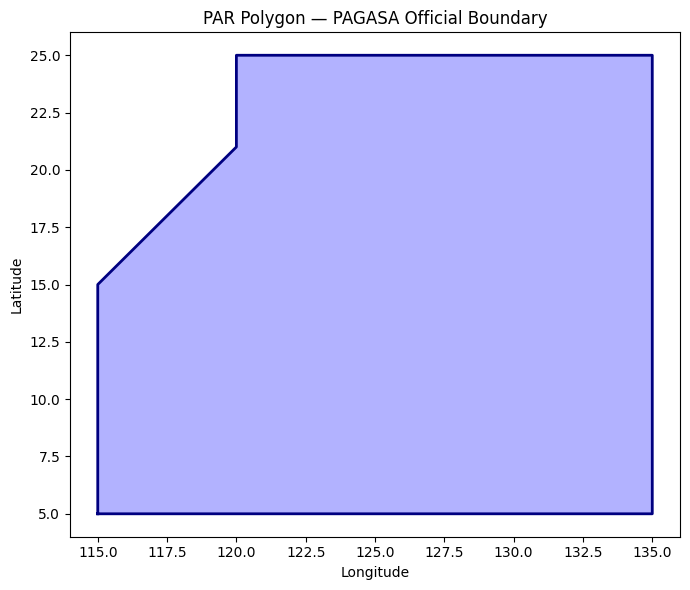

PAR polygon area (sq degrees): 365.0


In [6]:
par_polygon = Polygon([
    (115, 5),   
    (115, 15),  
    (120, 21), 
    (120, 25),  
    (135, 25),  
    (135, 5),   
    (115, 5)    
])

fig, ax = plt.subplots(figsize=(7, 6))
x, y = par_polygon.exterior.xy
ax.fill(x, y, alpha=0.3, color='blue')
ax.plot(x, y, color='navy', linewidth=2)
ax.set_title('PAR Polygon — PAGASA Official Boundary')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

print('PAR polygon area (sq degrees):', round(par_polygon.area, 2))

In [7]:
ibtracs_sem1 = ibtracs[ibtracs['month'].isin([6, 7, 8, 9, 10, 11])].copy()

print('Track points in Jun-Nov window:', len(ibtracs_sem1))
print('Unique storms in Jun-Nov:', ibtracs_sem1['storm_id'].nunique())

Track points in Jun-Nov window: 33951
Unique storms in Jun-Nov: 614


Filter Storms that entered PAR

In [8]:
def storm_entered_par(storm_df):
    for _, row in storm_df.iterrows():
        if par_polygon.contains(Point(row['lon'], row['lat'])):
            return True
    return False

par_storm_ids = (ibtracs_sem1.groupby('storm_id').filter(storm_entered_par)['storm_id'].unique())
ibtracs_par = ibtracs_sem1[ibtracs_sem1['storm_id'].isin(par_storm_ids)].copy()

print('Storms that entered PAR (Jun-Nov, 2000-2024):', len(par_storm_ids))
print('Track points:', len(ibtracs_par))

Storms that entered PAR (Jun-Nov, 2000-2024): 373
Track points: 21804


In [9]:
par_count_per_year = (ibtracs_par.groupby('year')['storm_id'].nunique().reset_index().rename(columns={'storm_id': 'par_storm_count'}))
print('PAR storm count per year:')
print(par_count_per_year.to_string(index=False))
print()
print('Min:', par_count_per_year['par_storm_count'].min(),
      '| Max:', par_count_per_year['par_storm_count'].max(),
      '| Mean:', round(par_count_per_year['par_storm_count'].mean(), 2))

ibtracs_par.to_csv('../data_clean/ibtracs_par_sem1.csv', index=False)
par_count_per_year.to_csv('../data_clean/par_count_per_year.csv', index=False)

PAR storm count per year:
 year  par_storm_count
 2000               15
 2001               13
 2002               11
 2003               16
 2004               17
 2005               14
 2006               15
 2007               13
 2008               15
 2009               17
 2010               12
 2011               13
 2012               17
 2013               23
 2014               14
 2015               10
 2016               13
 2017               19
 2018               19
 2019               16
 2020               20
 2021               12
 2022               15
 2023               10
 2024               14

Min: 10 | Max: 23 | Mean: 14.92


Severity scenario tercile split

In [10]:
par_count_per_year['scenario'] = pd.qcut(
    par_count_per_year['par_storm_count'],
    q=3,
    labels=['Normal', 'Moderate', 'Severe']
)
print('Scenario assignment:')
print(par_count_per_year.to_string(index=False))
print()
print('Semesters per scenario:')
print(par_count_per_year['scenario'].value_counts().sort_index())
print()
print('Storm count range per scenario:')
print(par_count_per_year.groupby('scenario')['par_storm_count'].agg(['min', 'max', 'mean']).round(2))

Scenario assignment:
 year  par_storm_count scenario
 2000               15 Moderate
 2001               13   Normal
 2002               11   Normal
 2003               16 Moderate
 2004               17   Severe
 2005               14 Moderate
 2006               15 Moderate
 2007               13   Normal
 2008               15 Moderate
 2009               17   Severe
 2010               12   Normal
 2011               13   Normal
 2012               17   Severe
 2013               23   Severe
 2014               14 Moderate
 2015               10   Normal
 2016               13   Normal
 2017               19   Severe
 2018               19   Severe
 2019               16 Moderate
 2020               20   Severe
 2021               12   Normal
 2022               15 Moderate
 2023               10   Normal
 2024               14 Moderate

Semesters per scenario:
scenario
Normal      9
Moderate    9
Severe      7
Name: count, dtype: int64

Storm count range per scenario:
          mi

In [26]:
par_count_per_year.to_csv('../data_clean/par_count_per_year.csv', index=False)

Region Affected by 200 km Buffer Rule:

In [29]:
geod = Geod(ellps='WGS84')
BUFFER_KM = 200
MIN_WIND_KNOTS = 21  # 39 km/h = ~21 knots = TCWS Signal 1 floor
                     # Source: PAGASA TCWS table (2022 revision)

def min_distance_to_region_km(track_lats, track_lons, region_geometry):
    min_dist = np.inf
    for lat, lon in zip(track_lats, track_lons):
        point = Point(lon, lat)
        nearest_on_region = nearest_points(point, region_geometry)[1]
        _, _, dist_m = geod.inv(
            lon, lat,
            nearest_on_region.x,
            nearest_on_region.y
        )
        dist_km = dist_m / 1000
        if dist_km < min_dist:
            min_dist = dist_km
    return min_dist

exposure_records = []
storm_groups = list(ibtracs_par.groupby('storm_id'))

for i, (storm_id, storm_df) in enumerate(tqdm(storm_groups, desc='Processing storms')):
    track_lats = storm_df['lat'].values
    track_lons = storm_df['lon'].values
    peak_wind  = storm_df['wind_speed'].max()
    year       = storm_df['year'].iloc[0]

    # cond 2: skip storm if peak wind below signal 1
    if pd.isna(peak_wind) or peak_wind < MIN_WIND_KNOTS:
        continue

    for _, region_row in regions_gdf.iterrows():
        region_name     = region_row['region']
        region_geometry = region_row['geometry']

        min_dist = min_distance_to_region_km(
            track_lats, track_lons, region_geometry
        )

        # cond 1: if within 200km

        if min_dist <= BUFFER_KM:
            exposure_records.append({
                'storm_id':    storm_id,
                'year':        year,
                'region':      region_name,
                'min_dist_km': round(min_dist, 2),
                'peak_wind':   peak_wind
            })

    if (i + 1) % 50 == 0:
        checkpoint_df = pd.DataFrame(exposure_records)
        checkpoint_df.to_csv('../data_clean/exposure_table_checkpoint.csv', index=False)
        print(f'Checkpoint saved at storm {i + 1}/{len(storm_groups)}')

exposure_df = pd.DataFrame(exposure_records)
exposure_df.to_csv('../data_clean/exposure_table.csv', index=False)

print()
print('Storms skipped (below Signal 1 wind threshold):',
      sum(1 for _, g in storm_groups if g['wind_speed'].max() < MIN_WIND_KNOTS))
print('Total affected region-storm pairs:', len(exposure_df))
print('Exported: exposure_table.csv')
exposure_df.head(10)


Processing storms:  13%|█▎        | 50/373 [03:20<19:28,  3.62s/it]

Checkpoint saved at storm 50/373


Processing storms:  27%|██▋       | 100/373 [06:42<16:57,  3.73s/it]

Checkpoint saved at storm 100/373


Processing storms:  40%|████      | 150/373 [09:16<11:27,  3.08s/it]

...

Processing storms:  94%|█████████▍| 350/373 [22:11<01:01,  2.68s/it]

Checkpoint saved at storm 350/373


Processing storms: 100%|██████████| 373/373 [23:52<00:00,  3.84s/it]


Storms skipped (below Signal 1 wind threshold): 0
Total affected region-storm pairs: 997
Exported: exposure_table.csv


,storm_id,year,region,min_dist_km,peak_wind
0,2000185N15117,2000,Region I (Ilocos Region),6.55,75.0
1,2000185N15117,2000,Region II (Cagayan Valley),37.56,75.0
2,2000185N15117,2000,Region III (Central Luzon),67.53,75.0
3,2000185N15117,2000,Cordillera Administrative Region (CAR),31.30,75.0
4,2000193N10131,2000,Region II (Cagayan Valley),126.76,22.0
5,2000193N10131,2000,Region III (Central Luzon),112.93,22.0
6,2000193N10131,2000,Region IV-A (Calabarzon),130.37,22.0
7,2000193N10131,2000,Region V (Bicol Region),133.92,22.0
8,2000202N12131,2000,Region II (Cagayan Valley),122.11,50.0
9,2000202N12131,2000,Region III (Central Luzon),183.62,50.0


Convert wind speed to TCWS levels


In [15]:
exposure_df = pd.read_csv('../data_clean/exposure_table.csv')

def assign_tcws(wind_knots):
    wind_kmh = wind_knots * 1.852

    if wind_kmh >= 185:
        return 5
    elif wind_kmh >= 118:
        return 4
    elif wind_kmh >= 89:
        return 3
    elif wind_kmh >= 62:
        return 2
    elif wind_kmh >= 39:
        return 1
    else:
        return np.nan

exposure_df['tcws'] = exposure_df['peak_wind'].apply(assign_tcws)
before = len(exposure_df)
exposure_df = exposure_df.dropna(subset=['tcws'])
exposure_df['tcws'] = exposure_df['tcws'].astype(int)
after = len(exposure_df)

print('Rows dropped (below Signal 1):', before - after)
print('TCWS distribution across all affected region-storm pairs:')
print(exposure_df['tcws'].value_counts().sort_index())
print(exposure_df.head(10))
exposure_df.to_csv('../data_clean/exposure_table.csv', index=False)

Rows dropped (below Signal 1): 0
TCWS distribution across all affected region-storm pairs:
tcws
1     85
2    235
3    164
4    304
5    209
Name: count, dtype: int64
        storm_id  year                                  region  min_dist_km  \
0  2000185N15117  2000                Region I (Ilocos Region)         6.55   
1  2000185N15117  2000              Region II (Cagayan Valley)        37.56   
2  2000185N15117  2000              Region III (Central Luzon)        67.53   
3  2000185N15117  2000  Cordillera Administrative Region (CAR)        31.30   
4  2000193N10131  2000              Region II (Cagayan Valley)       126.76   
5  2000193N10131  2000              Region III (Central Luzon)       112.93   
6  2000193N10131  2000                Region IV-A (Calabarzon)       130.37   
7  2000193N10131  2000                 Region V (Bicol Region)       133.92   
8  2000202N12131  2000              Region II (Cagayan Valley)       122.11   
9  2000202N12131  2000              Region 

In [16]:
exposure_df = exposure_df.merge(
    par_count_per_year[['year', 'scenario']],
    on='year',
    how='left'
)

unmatched = exposure_df['scenario'].isna().sum()
print('Unmatched rows (no scenario label):', unmatched)

print('Exposure table with scenario labels:')
print(exposure_df.head(10))

print('Row count per scenario:')
print(exposure_df['scenario'].value_counts().sort_index())
exposure_df.to_csv('../data_clean/exposure_table.csv', index=False)

Unmatched rows (no scenario label): 0
Exposure table with scenario labels:
        storm_id  year                                  region  min_dist_km  \
0  2000185N15117  2000                Region I (Ilocos Region)         6.55   
1  2000185N15117  2000              Region II (Cagayan Valley)        37.56   
2  2000185N15117  2000              Region III (Central Luzon)        67.53   
3  2000185N15117  2000  Cordillera Administrative Region (CAR)        31.30   
4  2000193N10131  2000              Region II (Cagayan Valley)       126.76   
5  2000193N10131  2000              Region III (Central Luzon)       112.93   
6  2000193N10131  2000                Region IV-A (Calabarzon)       130.37   
7  2000193N10131  2000                 Region V (Bicol Region)       133.92   
8  2000202N12131  2000              Region II (Cagayan Valley)       122.11   
9  2000202N12131  2000              Region III (Central Luzon)       183.62   

   peak_wind  tcws  scenario  
0       75.0     4  Mode

Lambda distribution per region-scenario pair

In [ ]:
all_regions   = regions_gdf['region'].unique()
all_years_df  = par_count_per_year[['year', 'scenario']]

full_index = pd.MultiIndex.from_product(
    [all_regions, all_years_df['year']],
    names=['region', 'year']
).to_frame(index=False)

full_index = full_index.merge(all_years_df, on='year', how='left')

storms_per_region_year = (
    exposure_df
    .groupby(['region', 'year'])['storm_id']
    .nunique()
    .reset_index()
    .rename(columns={'storm_id': 'storm_count'})
)

full_index = full_index.merge(
    storms_per_region_year,
    on=['region', 'year'],
    how='left'
)
full_index['storm_count'] = full_index['storm_count'].fillna(0)

lambda_table = (
    full_index
    .groupby(['region', 'scenario'])['storm_count']
    .mean()
    .reset_index()
    .rename(columns={'storm_count': 'lambda'})
    .round({'lambda': 4})
)

print('Lambda table sample:')
print(lambda_table.head(10))

Lambda table sample:
                                              region  scenario  lambda
0  Bangsamoro Autonomous Region In Muslim Mindana...    Normal  0.2222
1  Bangsamoro Autonomous Region In Muslim Mindana...  Moderate  0.3333
2  Bangsamoro Autonomous Region In Muslim Mindana...    Severe  0.5714
3             Cordillera Administrative Region (CAR)    Normal  4.1111
4             Cordillera Administrative Region (CAR)  Moderate  4.6667
5             Cordillera Administrative Region (CAR)    Severe  5.1429
6                                    Mimaropa Region    Normal  2.2222
7                                    Mimaropa Region  Moderate  3.1111
8                                    Mimaropa Region    Severe  4.0000
9                      National Capital Region (NCR)    Normal  1.5556


In [27]:
tcws_counts = (
    exposure_df
    .groupby(['region', 'scenario', 'tcws'])
    .size()
    .reset_index(name='count')
)

tcws_totals = tcws_counts.groupby(
    ['region', 'scenario']
)['count'].transform('sum')

tcws_counts['proportion'] = tcws_counts['count'] / tcws_totals

tcws_dist = tcws_counts.pivot_table(
    index=['region', 'scenario'],
    columns='tcws',
    values='proportion',
    fill_value=0
).reset_index()

tcws_dist.columns.name = None
tcws_dist = tcws_dist.rename(columns={
    1: 'prob_signal1',
    2: 'prob_signal2',
    3: 'prob_signal3',
    4: 'prob_signal4',
    5: 'prob_signal5'
})
for col in ['prob_signal1', 'prob_signal2', 'prob_signal3', 'prob_signal4', 'prob_signal5']:
    if col not in tcws_dist.columns:
        tcws_dist[col] = 0.0

param_table = lambda_table.merge(
    tcws_dist,
    on=['region', 'scenario'],
    how='left'
)

for col in ['prob_signal1', 'prob_signal2', 'prob_signal3', 'prob_signal4', 'prob_signal5']:
    param_table[col] = param_table[col].fillna(0)

print('Final parameter table:')
print(f'Shape: {param_table.shape}')
print(param_table.head(10))

prob_cols = ['prob_signal1', 'prob_signal2', 'prob_signal3', 'prob_signal4', 'prob_signal5']
param_table[prob_cols] = param_table[prob_cols].round(4)

param_table.to_csv('../data_clean/simulation_parameters.csv', index=False)

Final parameter table:
Shape: (51, 8)
                                              region  scenario  lambda  \
0  Bangsamoro Autonomous Region In Muslim Mindana...    Normal  0.2222   
1  Bangsamoro Autonomous Region In Muslim Mindana...  Moderate  0.3333   
2  Bangsamoro Autonomous Region In Muslim Mindana...    Severe  0.5714   
3             Cordillera Administrative Region (CAR)    Normal  4.1111   
4             Cordillera Administrative Region (CAR)  Moderate  4.6667   
5             Cordillera Administrative Region (CAR)    Severe  5.1429   
6                                    Mimaropa Region    Normal  2.2222   
7                                    Mimaropa Region  Moderate  3.1111   
8                                    Mimaropa Region    Severe  4.0000   
9                      National Capital Region (NCR)    Normal  1.5556   

   prob_signal1  prob_signal2  prob_signal3  prob_signal4  prob_signal5  
0      1.000000      0.000000      0.000000      0.000000      0.000000  